In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import os

In [2]:
PATHOGENS = ["abaumannii", "calbicans", "campylobacter", "ecoli", "efaecium", 
    "enterobacter", "hpylori", "kpneumoniae", "mtuberculosis", 
    "ngonorrhoeae", "paeruginosa", "pfalciparum", "saureus", 
    "smansoni", "spneumoniae"]

PATH_TO_OUTPUT = "../output"

In [3]:
num_mols_original, num_mols_cleaned = [], []
num_tasks, num_modelable_tasks = [], []
names = []

for pathogen in PATHOGENS:

    # Read data
    # data_pathogen = pd.read_csv(os.path.join(PATH_TO_OUTPUT, pathogen, f"016_{pathogen}_summary.csv"))
    names.append(pathogen)

    # Number of molecules original
    try:
        num_mols_original.append(len(open(os.path.join(PATH_TO_OUTPUT, pathogen, f"011_{pathogen}_original.csv")).readlines()) - 1)
    except:
        num_mols_original.append(0)

    # Number of molecules cleaned
    try:
        num_mols_cleaned.append(len(open(os.path.join(PATH_TO_OUTPUT, pathogen, f"012_{pathogen}_cleaned.csv")).readlines()) - 1)
    except:
        num_mols_cleaned.append(0)

    # Number of tasks
    try:
        num_tasks.append(len(os.listdir(os.path.join(PATH_TO_OUTPUT, pathogen, "013_raw_tasks"))))
    except:
        num_tasks.append(0)

    # Number of selcted tasks
    try:
        num_modelable_tasks.append(len(os.listdir(os.path.join(PATH_TO_OUTPUT, pathogen, "016_tasks"))))
    except:
        num_modelable_tasks.append(0)


num_mols_original = np.array(num_mols_original)
num_mols_cleaned = np.array(num_mols_cleaned)
num_tasks = np.array(num_tasks)
num_modelable_tasks = np.array(num_modelable_tasks)
names = np.array(names)

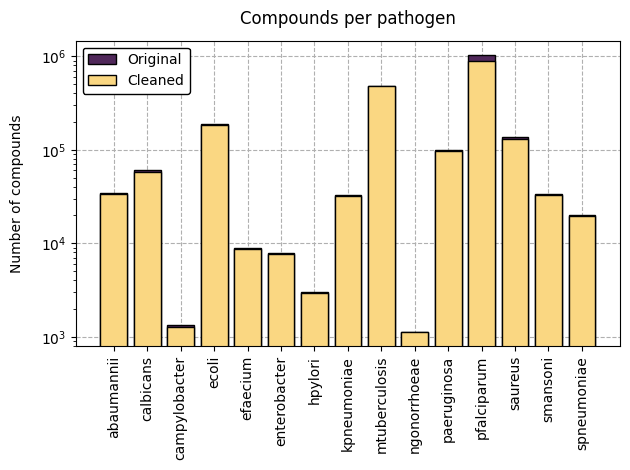

In [4]:
plt.bar([i for i in range(len(names))], num_mols_original, ec='k', color='#50285aff', zorder=2)
plt.bar([i for i in range(len(names))], num_mols_cleaned, ec='k', color='#fad782ff', zorder=2)
plt.yscale('log')
plt.xticks([i for i in range(len(names))], names, rotation=90)

plt.title("Compounds per pathogen", pad=12)
plt.grid(linestyle='--', zorder=-2)
plt.ylabel("Number of compounds", labelpad=12)
legend_patches = [mpatches.Patch(color='#50285aff', label='Original', ec='k'), mpatches.Patch(color='#fad782ff', label='Cleaned', ec='k')]
plt.legend(handles=legend_patches, loc='upper left', edgecolor='k', framealpha=1)
plt.tight_layout()
plt.savefig("../plots/num_compounds.png", dpi=300)
plt.show()

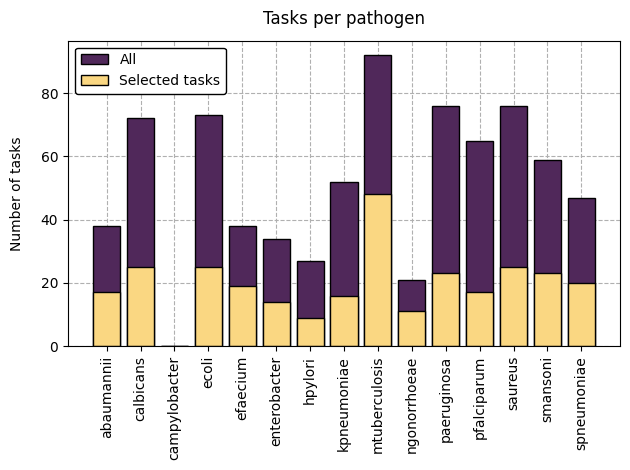

In [6]:
plt.bar([i for i in range(len(names))], num_tasks, ec='k', color='#50285aff', zorder=2)
plt.bar([i for i in range(len(names))], num_modelable_tasks, ec='k', color='#fad782ff', zorder=2)
plt.xticks([i for i in range(len(names))], names, rotation=90)

plt.title("Tasks per pathogen", pad=12)
plt.grid(linestyle='--', zorder=-2)
plt.ylabel("Number of tasks", labelpad=12)
legend_patches = [mpatches.Patch(color='#50285aff', label='All', ec='k'), mpatches.Patch(color='#fad782ff', label='Selected tasks', ec='k')]
plt.legend(handles=legend_patches, loc='upper left', edgecolor='k', framealpha=1)
plt.tight_layout()
plt.savefig("../plots/num_tasks.png", dpi=300)
plt.show()

abaumannii


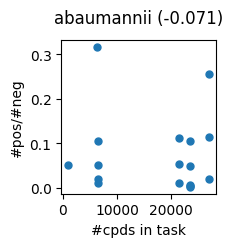

In [42]:
for name in names:

    if name != "campylobacter":

        # Load tasks data
        df = pd.read_csv(os.path.join(PATH_TO_OUTPUT, name, "016_tasks_summary.csv"))
        print(name)

        # Get data
        num_samples = df['num_samples'].tolist()
        pos_neg_prop = df['pos:neg'].tolist()
        corr = round(np.corrcoef(num_samples, pos_neg_prop)[0, 1], 3)

        plt.figure(figsize=(2, 2))
        plt.scatter(num_samples, pos_neg_prop, s=25)
        plt.title(name + f" ({corr})", pad=12)
        plt.xlabel("#cpds in task")
        plt.ylabel("#pos/#neg")
        plt.show()

    break

-0.071

In [20]:
num_samples

[21482,
 21482,
 21482,
 1032,
 6514,
 6533,
 6307,
 6524,
 6514,
 23407,
 23393,
 23392,
 23392,
 23392,
 26982,
 26886,
 27011]

In [9]:
num_mols_cleaned

array([ 33654,  58440,   1261, 181665,   8601,   7617,   2910,  32144,
       476773,   1116,  97026, 889813, 129537,  32678,  19409])

In [ ]:
num